In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
pc_features = np.load('/media/ubuntu/sda/Monkey/semantic/epoch_10/pc_results/pca_results.npz', allow_pickle=True)
image_inf = pd.read_csv("/media/ubuntu/sda/Monkey/data/train_image_MonkeyF.csv")

In [12]:
image_inf

,class,local_path,things_path
0,aardvark,/media/ubuntu/sda/visual_stimuli_pattern/thing...,aardvark/aardvark_01b.jpg
1,aardvark,/media/ubuntu/sda/visual_stimuli_pattern/thing...,aardvark/aardvark_02s.jpg
2,aardvark,/media/ubuntu/sda/visual_stimuli_pattern/thing...,aardvark/aardvark_03s.jpg
3,aardvark,/media/ubuntu/sda/visual_stimuli_pattern/thing...,aardvark/aardvark_04s.jpg
4,aardvark,/media/ubuntu/sda/visual_stimuli_pattern/thing...,aardvark/aardvark_05s.jpg
...,...,...,...
22243,zucchini,/media/ubuntu/sda/visual_stimuli_pattern/thing...,zucchini/zucchini_08n.jpg
22244,zucchini,/media/ubuntu/sda/visual_stimuli_pattern/thing...,zucchini/zucchini_09s.jpg
22245,zucchini,/media/ubuntu/sda/visual_stimuli_pattern/thing...,zucchini/zucchini_10s.jpg
22246,zucchini,/media/ubuntu/sda/visual_stimuli_pattern/thing...,zucchini/zucchini_11s.jpg


In [11]:
features_40d = pc_features['features_40d']

In [16]:
from scipy.spatial.distance import pdist
import numpy as np

# 获取所有类别
classes = image_inf['class'].unique()
print(f"总共有 {len(classes)} 个类别")

# 计算同一类别内的距离和不同类别之间的距离
intra_class_distances = []  # 同一类别内的距离
inter_class_distances = []  # 不同类别之间的距离

# 对每个类别计算内部距离
for class_name in classes:
    # 获取该类别所有图像的索引
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    
    if len(class_indices) > 1:
        # 获取该类别对应的特征
        class_features = features_40d[class_indices]
        
        # 计算该类别内所有图像对之间的欧氏距离
        class_distances = pdist(class_features, metric='euclidean')
        intra_class_distances.extend(class_distances)

# 计算不同类别之间的距离
# 为了计算效率，我们随机采样一些不同类别的图像对
np.random.seed(42)
max_inter_pairs = 50000  # 总共采样的不同类别间图像对数量

# 随机选择类别对并采样图像对
sampled_pairs = 0
max_attempts = 100000  # 最大尝试次数，避免无限循环
attempts = 0

while sampled_pairs < max_inter_pairs and attempts < max_attempts:
    attempts += 1
    # 随机选择两个不同的类别
    class1, class2 = np.random.choice(classes, size=2, replace=False)
    
    class1_indices = image_inf[image_inf['class'] == class1].index.values
    class2_indices = image_inf[image_inf['class'] == class2].index.values
    
    if len(class1_indices) > 0 and len(class2_indices) > 0:
        # 随机选择每个类别中的一张图像
        idx1 = np.random.choice(class1_indices)
        idx2 = np.random.choice(class2_indices)
        
        # 计算距离
        distance = np.linalg.norm(features_40d[idx1] - features_40d[idx2])
        inter_class_distances.append(distance)
        sampled_pairs += 1

intra_class_distances = np.array(intra_class_distances)
inter_class_distances = np.array(inter_class_distances)

print(f"同一类别内的距离数量: {len(intra_class_distances)}")
print(f"不同类别之间的距离数量: {len(inter_class_distances)}")
if len(intra_class_distances) > 0:
    print(f"同一类别内平均距离: {np.mean(intra_class_distances):.4f}")
if len(inter_class_distances) > 0:
    print(f"不同类别间平均距离: {np.mean(inter_class_distances):.4f}")
else:
    print("警告: 没有计算到不同类别间的距离，请检查数据")


总共有 1854 个类别
同一类别内的距离数量: 122364
不同类别之间的距离数量: 50000
同一类别内平均距离: 13.9664
不同类别间平均距离: 20.8184


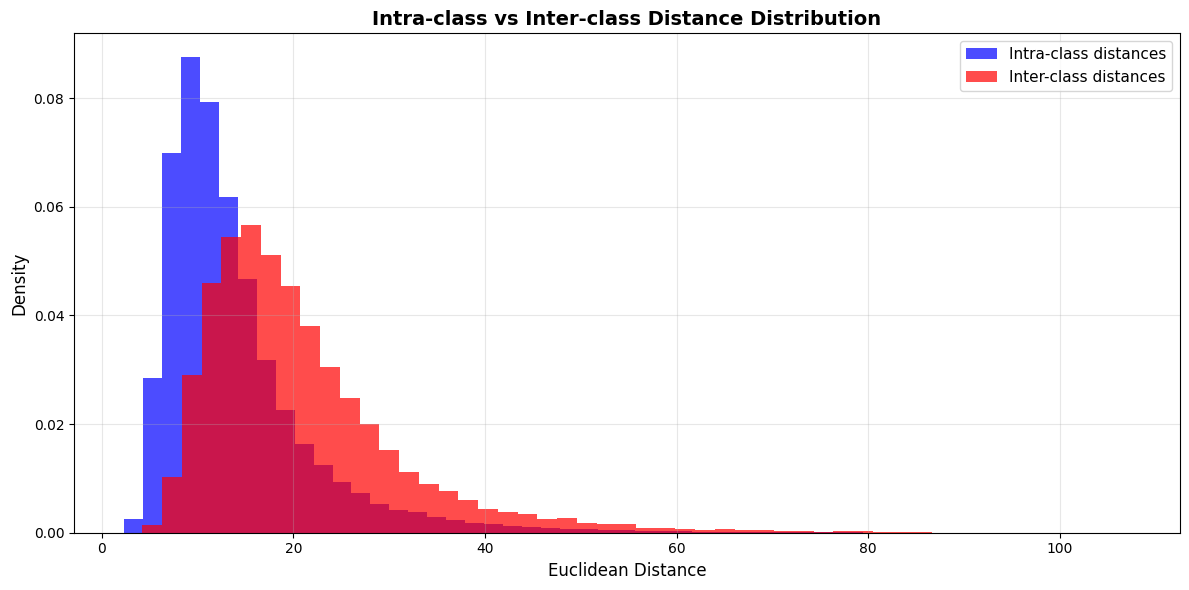


统计摘要:
同一类别内距离 - 均值: 13.9664, 标准差: 8.1421
不同类别间距离 - 均值: 20.8184, 标准差: 10.4547

距离比 (同一类别/不同类别): 0.6709
✓ 同一类别的图像在特征空间中更接近（聚类效果好）


In [17]:
# 绘制直方图比较同一类别内和不同类别之间的距离分布
if len(intra_class_distances) > 0 and len(inter_class_distances) > 0:
    plt.figure(figsize=(12, 6))
    
    # 绘制直方图
    plt.hist(intra_class_distances, bins=50, alpha=0.7, label='Intra-class distances', color='blue', density=True)
    plt.hist(inter_class_distances, bins=50, alpha=0.7, label='Inter-class distances', color='red', density=True)
    
    plt.xlabel('Euclidean Distance', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Intra-class vs Inter-class Distance Distribution', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print("\n统计摘要:")
    print(f"同一类别内距离 - 均值: {np.mean(intra_class_distances):.4f}, 标准差: {np.std(intra_class_distances):.4f}")
    print(f"不同类别间距离 - 均值: {np.mean(inter_class_distances):.4f}, 标准差: {np.std(inter_class_distances):.4f}")
    ratio = np.mean(intra_class_distances) / np.mean(inter_class_distances)
    print(f"\n距离比 (同一类别/不同类别): {ratio:.4f}")
    if ratio < 1:
        print("✓ 同一类别的图像在特征空间中更接近（聚类效果好）")
    else:
        print("✗ 同一类别的图像在特征空间中不够接近（聚类效果差）")
else:
    print("无法绘制图表：缺少距离数据")


/tmp/ipykernel_3477245/3779664246.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


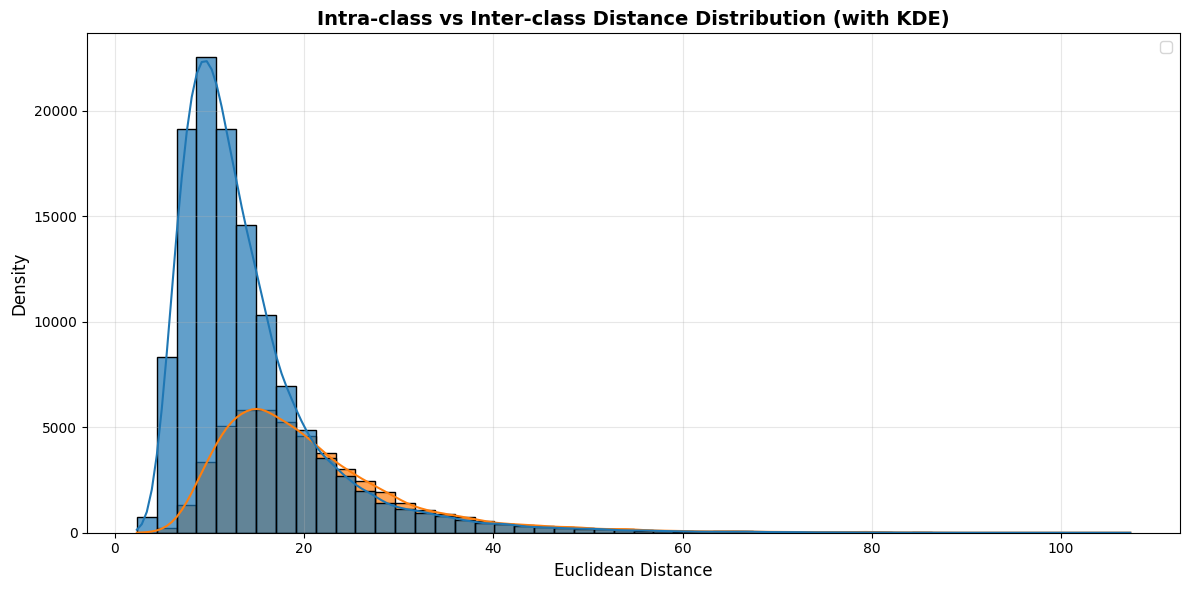

In [18]:
# 使用seaborn绘制更美观的直方图（备选版本）
if len(intra_class_distances) > 0 and len(inter_class_distances) > 0:
    plt.figure(figsize=(12, 6))
    
    # 准备数据
    df_distances = pd.DataFrame({
        'Distance': np.concatenate([intra_class_distances, inter_class_distances]),
        'Type': ['Intra-class'] * len(intra_class_distances) + ['Inter-class'] * len(inter_class_distances)
    })
    
    # 使用seaborn绘制
    sns.histplot(data=df_distances, x='Distance', hue='Type', bins=50, alpha=0.7, kde=True)
    
    plt.xlabel('Euclidean Distance', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Intra-class vs Inter-class Distance Distribution (with KDE)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("无法绘制图表：缺少距离数据")


In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 提取前10个PCA维度
features_10d = features_40d[:, :10]
print(f"特征维度: {features_10d.shape}")

# 进行K-means聚类，分成10个cluster
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features_10d)



特征维度: (22248, 10)


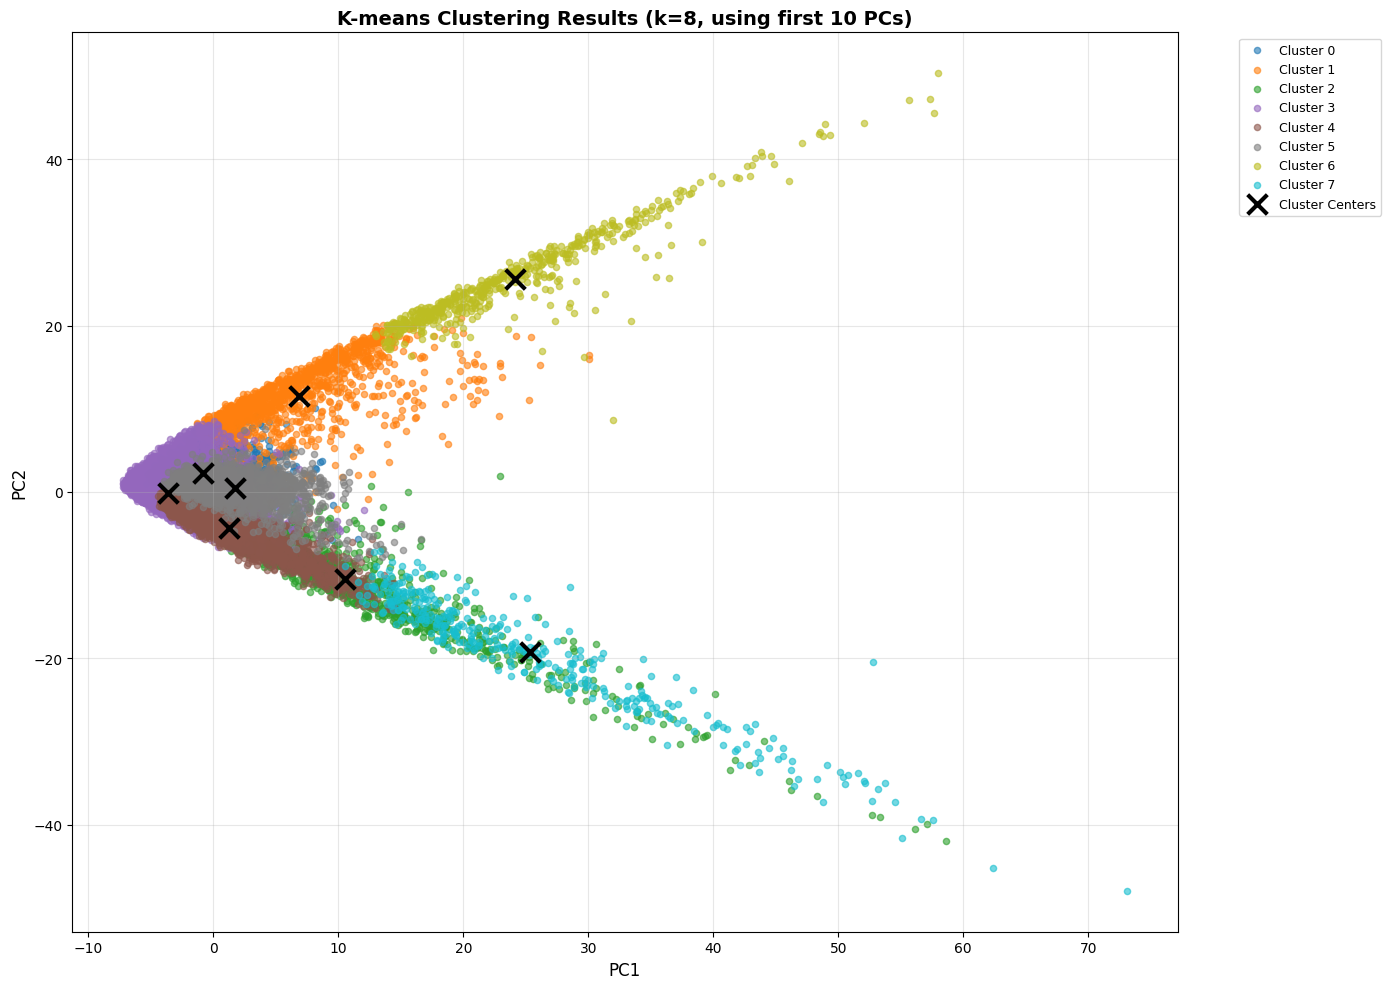

In [65]:
# 使用前两个PCA维度可视化聚类结果
plt.figure(figsize=(14, 10))

# 为每个cluster分配不同颜色
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    plt.scatter(features_40d[cluster_mask, 0], 
                features_40d[cluster_mask, 1],
                c=[colors[i]], 
                label=f'Cluster {i}',
                alpha=0.6,
                s=20)

# 绘制聚类中心（使用前两个维度）
centers_2d = kmeans.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            c='black', marker='x', s=200, linewidths=3,
            label='Cluster Centers', zorder=10)

plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title(f'K-means Clustering Results (k={n_clusters}, using first 10 PCs)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [66]:
# 根据规则定义class到cluster的映射：如果某个class有超过10张图片在某个cluster中，认为这个class属于这个cluster
threshold = 10  # 阈值：超过10张图片

# 统计每个class在每个cluster中的数量
class_cluster_matrix = {}
class_to_cluster = {}  # 记录每个class属于哪个cluster

for class_name in classes:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    class_cluster_counts = {}
    
    # 统计该class在每个cluster中的数量
    for cluster_id in range(n_clusters):
        cluster_mask = cluster_labels == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        
        # 计算该class在这个cluster中的数量
        count = len(np.intersect1d(class_indices, cluster_indices))
        class_cluster_counts[cluster_id] = count
    
    class_cluster_matrix[class_name] = class_cluster_counts
    
    # 找到超过阈值的cluster
    matching_clusters = [cid for cid, count in class_cluster_counts.items() if count > threshold]
    
    if len(matching_clusters) == 1:
        # 只有一个cluster超过阈值，直接分配
        class_to_cluster[class_name] = matching_clusters[0]
    elif len(matching_clusters) > 1:
        # 多个cluster超过阈值，选择数量最多的
        best_cluster = max(matching_clusters, key=lambda x: class_cluster_counts[x])
        class_to_cluster[class_name] = best_cluster
    else:
        # 没有cluster超过阈值，选择数量最多的cluster
        best_cluster = max(class_cluster_counts.items(), key=lambda x: x[1])[0]
        class_to_cluster[class_name] = best_cluster

print(f"总共 {len(classes)} 个类别")
print(f"阈值设置: 超过 {threshold} 张图片")
print(f"\n类别到Cluster的映射统计:")

# 统计每个cluster包含多少个class
cluster_class_counts = {}
for class_name, assigned_cluster in class_to_cluster.items():
    if assigned_cluster not in cluster_class_counts:
        cluster_class_counts[assigned_cluster] = []
    cluster_class_counts[assigned_cluster].append(class_name)

for cluster_id in range(n_clusters):
    count = len(cluster_class_counts.get(cluster_id, []))
    print(f"  Cluster {cluster_id}: {count} 个类别")


总共 1854 个类别
阈值设置: 超过 10 张图片

类别到Cluster的映射统计:
  Cluster 0: 146 个类别
  Cluster 1: 117 个类别
  Cluster 2: 64 个类别
  Cluster 3: 1173 个类别
  Cluster 4: 152 个类别
  Cluster 5: 158 个类别
  Cluster 6: 36 个类别
  Cluster 7: 8 个类别


In [22]:
# 详细显示每个cluster包含的类别
print("\n" + "=" * 80)
print("每个Cluster包含的类别详情:")
print("=" * 80)

for cluster_id in range(n_clusters):
    cluster_classes = cluster_class_counts.get(cluster_id, [])
    if len(cluster_classes) > 0:
        print(f"\nCluster {cluster_id} (包含 {len(cluster_classes)} 个类别):")
        
        # 显示前20个类别
        for i, class_name in enumerate(cluster_classes[:20]):
            class_indices = image_inf[image_inf['class'] == class_name].index.values
            cluster_mask = cluster_labels == cluster_id
            cluster_indices = np.where(cluster_mask)[0]
            count = len(np.intersect1d(class_indices, cluster_indices))
            print(f"  {class_name}: {count}/12 张图片")
        
        if len(cluster_classes) > 20:
            print(f"  ... 还有 {len(cluster_classes) - 20} 个类别")
    else:
        print(f"\nCluster {cluster_id}: 没有分配的类别")



每个Cluster包含的类别详情:

Cluster 0 (包含 148 个类别):
  acorn: 10/12 张图片
  almond: 10/12 张图片
  aloe: 7/12 张图片
  apple: 9/12 张图片
  apple_tree: 6/12 张图片
  artichoke: 11/12 张图片
  arugula: 12/12 张图片
  asparagus: 11/12 张图片
  avocado: 9/12 张图片
  banana: 9/12 张图片
  basil: 12/12 张图片
  bead: 6/12 张图片
  bean: 10/12 张图片
  beet: 8/12 张图片
  bell_pepper: 11/12 张图片
  berry: 7/12 张图片
  blackberry: 9/12 张图片
  blueberry: 10/12 张图片
  bok_choy: 11/12 张图片
  broccoli: 9/12 张图片
  ... 还有 128 个类别

Cluster 1 (包含 19 个类别):
  canvas: 11/12 张图片
  foam: 4/12 张图片
  gauze: 4/12 张图片
  handkerchief: 4/12 张图片
  light_switch: 5/12 张图片
  mattress: 5/12 张图片
  napkin: 6/12 张图片
  notebook: 9/12 张图片
  notepad: 7/12 张图片
  paper: 8/12 张图片
  paper_bag: 3/12 张图片
  paper_plate: 10/12 张图片
  plate: 4/12 张图片
  screen1: 11/12 张图片
  tablecloth: 3/12 张图片
  toilet_paper: 5/12 张图片
  touchpad: 6/12 张图片
  wax_paper: 4/12 张图片
  whiteboard: 5/12 张图片

Cluster 2 (包含 206 个类别):
  ankle: 10/12 张图片
  anklet: 12/12 张图片
  apron: 9/12 张图片
  baby: 9/12 张图片
  bag:

In [67]:
# 保存class到cluster的映射结果
# 创建映射DataFrame
mapping_df = pd.DataFrame({
    'class': list(class_to_cluster.keys()),
    'assigned_cluster': list(class_to_cluster.values())
})

# 添加每个class在分配到的cluster中的图片数量
image_counts = []
for class_name in mapping_df['class']:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    assigned_cluster = class_to_cluster[class_name]
    cluster_mask = cluster_labels == assigned_cluster
    cluster_indices = np.where(cluster_mask)[0]
    count = len(np.intersect1d(class_indices, cluster_indices))
    image_counts.append(count)

mapping_df['images_in_cluster'] = image_counts
mapping_df['meets_threshold'] = mapping_df['images_in_cluster'] > threshold

# 按cluster排序
mapping_df = mapping_df.sort_values('assigned_cluster')

# 保存为CSV
mapping_output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10/class_to_cluster_mapping.csv'
mapping_df.to_csv(mapping_output_path, index=False)
print(f"类别到Cluster的映射已保存到: {mapping_output_path}")

# 保存为字典格式（npz）
mapping_dict = {
    'class_to_cluster': class_to_cluster,
    'cluster_to_classes': cluster_class_counts,
    'threshold': threshold,
    'class_cluster_matrix': class_cluster_matrix
}

mapping_npz_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10/class_to_cluster_mapping.npz'
np.savez(mapping_npz_path, **mapping_dict)
print(f"映射字典已保存到: {mapping_npz_path}")


类别到Cluster的映射已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10/class_to_cluster_mapping.csv
映射字典已保存到: /media/ubuntu/sda/Monkey/semantic/epoch_10/class_to_cluster_mapping.npz


In [68]:
# 使用UMAP进行降维可视化
try:
    import umap
    print("UMAP库已导入")
except ImportError:
    print("正在安装UMAP库...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'umap-learn'])
    import umap
    print("UMAP库安装完成")

# 使用前10个PCA维度进行UMAP降维（与K-means聚类使用的特征一致）
print(f"输入特征维度: {features_10d.shape}")

# 创建UMAP模型
reducer = umap.UMAP(n_components=3, 
                    random_state=3,
                    n_neighbors=15,
                    min_dist=0.1,
                    metric='euclidean')

# 执行降维
print("正在进行UMAP降维...")
umap_embedding = reducer.fit_transform(features_10d)
print(f"UMAP降维完成，输出维度: {umap_embedding.shape}")


UMAP库已导入
输入特征维度: (22248, 10)
正在进行UMAP降维...


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP降维完成，输出维度: (22248, 3)


In [69]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

# 生成tab20颜色
n_clusters = len(np.unique(cluster_labels))
tab20_colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
# 将matplotlib RGBA转换为plotly可用的颜色格式
tab20_hex = [f'rgba({int(r*255)},{int(g*255)},{int(b*255)},{a})' 
             for r, g, b, a in tab20_colors]

# 创建颜色映射字典
color_map = {i: tab20_hex[i] for i in range(n_clusters)}

# 创建数据
data = []
for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    trace = go.Scatter3d(
        x=umap_embedding[cluster_mask, 0],
        y=umap_embedding[cluster_mask, 1],
        z=umap_embedding[cluster_mask, 2],
        mode='markers',
        marker=dict(
            size=1,
            color=tab20_hex[i],  # 使用tab20颜色
            opacity=1,
            line=dict(width=0)
        ),
        name=f'Cluster {i}',
        hovertemplate=(
            'Cluster: %{text}<br>' +
            'UMAP1: %{x:.3f}<br>' +
            'UMAP2: %{y:.3f}<br>' +
            'UMAP3: %{z:.3f}<extra></extra>'
        ),
        text=[f'Cluster {i}'] * np.sum(cluster_mask)
    )
    data.append(trace)

layout = go.Layout(
    title=dict(
        text='3D UMAP Visualization Colored by K-means Clusters',
        font=dict(size=20, family='Arial', color='black'),
        x=0.5
    ),
    scene=dict(
        xaxis=dict(
            title='UMAP 1',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        yaxis=dict(
            title='UMAP 2',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        zaxis=dict(
            title='UMAP 3',
            gridcolor='lightgray',
            showbackground=True,
            backgroundcolor='white'
        ),
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
        aspectmode='data'
    ),
    legend=dict(
        title=dict(text='Clusters'),
        font=dict(size=12),
        itemsizing='constant',
        x=1.02,
        y=1,
        xanchor='left',
        yanchor='top'
    ),
    width=1000,
    height=800,
    margin=dict(l=0, r=200, t=50, b=0),
    hovermode='closest'
)

# 创建图形
fig = go.Figure(data=data, layout=layout)

# 显示图形
fig.show()


In [70]:
# 合并cluster：cluster 1和6合并，cluster 7和4合并
print("原始cluster数量:", n_clusters)
print("合并规则:")
print("  - Cluster 1 和 Cluster 6 合并")
print("  - Cluster 7 和 Cluster 4 合并")

# 创建合并后的cluster标签
merged_cluster_labels = cluster_labels.copy()

# 合并策略：将较小的cluster编号合并到较大的cluster编号
# Cluster 1 和 6 -> 合并到 1
merged_cluster_labels[merged_cluster_labels == 6] = 1

# Cluster 7 和 4 -> 合并到 4
merged_cluster_labels[merged_cluster_labels == 7] = 4

# 重新映射cluster编号，使其连续（0-7）
# 原始cluster: 0, 1(包含6), 2, 3, 4(包含7), 5, 8, 9
# 需要重新映射为: 0, 1, 2, 3, 4, 5, 6, 7

# 创建映射字典
cluster_mapping = {
    0: 0,
    1: 1,  # 包含原来的1和6
    2: 2,
    3: 3,
    4: 4,  # 包含原来的4和7
    5: 5
}

# 应用映射
merged_cluster_labels_renumbered = np.array([cluster_mapping[label] for label in merged_cluster_labels])

# 更新cluster数量
n_merged_clusters = len(set(merged_cluster_labels_renumbered))
print(f"\n合并后cluster数量: {n_merged_clusters}")



原始cluster数量: 8
合并规则:
  - Cluster 1 和 Cluster 6 合并
  - Cluster 7 和 Cluster 4 合并

合并后cluster数量: 6


In [71]:
# 更新class到cluster的映射（基于合并后的cluster）
# 重新计算每个class在合并后cluster中的分布
merged_class_to_cluster = {}
merged_cluster_class_counts = {i: [] for i in range(n_merged_clusters)}

for class_name in classes:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    class_cluster_counts = {}
    
    # 统计该class在每个合并后cluster中的数量
    for cluster_id in range(n_merged_clusters):
        cluster_mask = merged_cluster_labels_renumbered == cluster_id
        cluster_indices = np.where(cluster_mask)[0]
        count = len(np.intersect1d(class_indices, cluster_indices))
        class_cluster_counts[cluster_id] = count
    
    # 找到超过阈值的cluster
    matching_clusters = [cid for cid, count in class_cluster_counts.items() if count > threshold]
    
    if len(matching_clusters) == 1:
        merged_class_to_cluster[class_name] = matching_clusters[0]
    elif len(matching_clusters) > 1:
        best_cluster = max(matching_clusters, key=lambda x: class_cluster_counts[x])
        merged_class_to_cluster[class_name] = best_cluster
    else:
        best_cluster = max(class_cluster_counts.items(), key=lambda x: x[1])[0]
        merged_class_to_cluster[class_name] = best_cluster
    
    # 添加到cluster的类别列表
    assigned_cluster = merged_class_to_cluster[class_name]
    merged_cluster_class_counts[assigned_cluster].append(class_name)




合并后类别到Cluster的映射统计:
  Cluster 0: 146 个类别
  Cluster 1: 155 个类别
  Cluster 2: 64 个类别
  Cluster 3: 1162 个类别
  Cluster 4: 169 个类别
  Cluster 5: 158 个类别


In [ ]:
# 可视化合并后的cluster（使用UMAP）
plt.figure(figsize=(14, 10))

# 为每个合并后的cluster分配不同颜色
colors = plt.cm.tab10(np.linspace(0, 1, n_merged_clusters))

for i in range(n_merged_clusters):
    cluster_mask = merged_cluster_labels_renumbered == i
    plt.scatter(umap_embedding[cluster_mask, 0], 
                umap_embedding[cluster_mask, 1],
                c=[colors[i]], 
                label=f'Cluster {i}',
                alpha=0.6,
                s=20)

plt.xlabel('UMAP 1', fontsize=12)
plt.ylabel('UMAP 2', fontsize=12)
plt.title('UMAP Visualization: Merged Clusters (1&6 merged, 7&4 merged)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# 对比原始cluster和合并后cluster
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 左图：原始cluster
ax1 = axes[0]
colors_original = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for i in range(n_clusters):
    cluster_mask = cluster_labels == i
    ax1.scatter(umap_embedding[cluster_mask, 0], 
                umap_embedding[cluster_mask, 1],
                c=[colors_original[i]], 
                label=f'Cluster {i}',
                alpha=0.6,
                s=20)
ax1.set_xlabel('UMAP 1', fontsize=12)
ax1.set_ylabel('UMAP 2', fontsize=12)
ax1.set_title('Original Clusters (10 clusters)', fontsize=14, fontweight='bold')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 右图：合并后的cluster
ax2 = axes[1]
colors_merged = plt.cm.tab10(np.linspace(0, 1, n_merged_clusters))
for i in range(n_merged_clusters):
    cluster_mask = merged_cluster_labels_renumbered == i
    ax2.scatter(umap_embedding[cluster_mask, 0], 
                umap_embedding[cluster_mask, 1],
                c=[colors_merged[i]], 
                label=f'Cluster {i}',
                alpha=0.6,
                s=20)
ax2.set_xlabel('UMAP 1', fontsize=12)
ax2.set_ylabel('UMAP 2', fontsize=12)
ax2.set_title('Merged Clusters (8 clusters)', fontsize=14, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# 保存合并后的cluster结果
# 创建合并后的映射DataFrame
merged_mapping_df = pd.DataFrame({
    'class': list(merged_class_to_cluster.keys()),
    'assigned_cluster': list(merged_class_to_cluster.values())
})

# 添加每个class在分配到的cluster中的图片数量
merged_image_counts = []
for class_name in merged_mapping_df['class']:
    class_indices = image_inf[image_inf['class'] == class_name].index.values
    assigned_cluster = merged_class_to_cluster[class_name]
    cluster_mask = merged_cluster_labels_renumbered == assigned_cluster
    cluster_indices = np.where(cluster_mask)[0]
    count = len(np.intersect1d(class_indices, cluster_indices))
    merged_image_counts.append(count)

merged_mapping_df['images_in_cluster'] = merged_image_counts
merged_mapping_df['meets_threshold'] = merged_mapping_df['images_in_cluster'] > threshold
merged_mapping_df = merged_mapping_df.sort_values('assigned_cluster')

# 保存为CSV
merged_mapping_output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10/class_to_cluster_mapping_merged.csv'
merged_mapping_df.to_csv(merged_mapping_output_path, index=False)
print(f"合并后的类别到Cluster映射已保存到: {merged_mapping_output_path}")

# 保存合并后的cluster标签
merged_cluster_results = {
    'merged_cluster_labels': merged_cluster_labels_renumbered,
    'original_cluster_labels': cluster_labels,
    'n_clusters': n_merged_clusters,
    'original_n_clusters': n_clusters,
    'merge_info': {
        'cluster_1_and_6_merged': True,
        'cluster_7_and_4_merged': True
    }
}

merged_cluster_output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10/merged_cluster_results.npz'
np.savez(merged_cluster_output_path, **merged_cluster_results)
print(f"合并后的cluster结果已保存到: {merged_cluster_output_path}")

# 更新image_inf_with_clusters
image_inf_with_merged_clusters = image_inf.copy()
image_inf_with_merged_clusters['original_cluster'] = cluster_labels
image_inf_with_merged_clusters['merged_cluster'] = merged_cluster_labels_renumbered
image_inf_with_merged_clusters['assigned_cluster'] = image_inf_with_merged_clusters['class'].map(merged_class_to_cluster)

merged_csv_output_path = '/media/ubuntu/sda/Monkey/semantic/epoch_10/image_inf_with_merged_clusters.csv'
image_inf_with_merged_clusters.to_csv(merged_csv_output_path, index=False)
print(f"带合并cluster标签的CSV已保存到: {merged_csv_output_path}")

print(f"\n合并结果摘要:")
print(f"  - 原始cluster数量: {n_clusters}")
print(f"  - 合并后cluster数量: {n_merged_clusters}")
print(f"  - 总类别数: {len(classes)}")
merged_meeting_threshold = merged_mapping_df['meets_threshold'].sum()
print(f"  - 满足阈值的类别: {merged_meeting_threshold} ({merged_meeting_threshold/len(classes)*100:.1f}%)")


In [ ]:
# 显示合并后每个cluster包含的类别详情
print("\n" + "=" * 80)
print("合并后每个Cluster包含的类别详情（Top 15类别）:")
print("=" * 80)

for cluster_id in range(n_merged_clusters):
    cluster_classes = merged_cluster_class_counts.get(cluster_id, [])
    if len(cluster_classes) > 0:
        print(f"\nCluster {cluster_id} (包含 {len(cluster_classes)} 个类别):")
        
        # 计算每个类别在该cluster中的图片数量并排序
        class_counts_in_cluster = []
        for class_name in cluster_classes:
            class_indices = image_inf[image_inf['class'] == class_name].index.values
            cluster_mask = merged_cluster_labels_renumbered == cluster_id
            cluster_indices = np.where(cluster_mask)[0]
            count = len(np.intersect1d(class_indices, cluster_indices))
            class_counts_in_cluster.append((class_name, count))
        
        # 按数量排序
        class_counts_in_cluster.sort(key=lambda x: x[1], reverse=True)
        
        # 显示前15个类别
        for i, (class_name, count) in enumerate(class_counts_in_cluster[:15]):
            percentage = (count / 12) * 100
            print(f"    {class_name}: {count}/12 张图片 ({percentage:.1f}%)")
        
        if len(cluster_classes) > 15:
            print(f"    ... 还有 {len(cluster_classes) - 15} 个类别")
        
        # 计算dominant class的比例
        if len(class_counts_in_cluster) > 0:
            dominant_ratio = (class_counts_in_cluster[0][1] / 12) * 100
            print(f"  主导类别占比: {dominant_ratio:.1f}%")
    else:
        print(f"\nCluster {cluster_id}: 没有分配的类别")
